<a href="https://colab.research.google.com/github/hassan1303/Vegetable_Image_Classification/blob/main/Vegetable_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ArewaDS Deep Learning Cohort 2.0 – Capstone Project  
### Project Title: Deep Learning-Based Vegetable Image Classification


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q wandb
import wandb
wandb.login()
wandb.init(project="vegetable-classification", name="ResNet18", reinit=True)





<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hassanmuhammadadam1 (hassanmuhammadadam1-bayero-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import random
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
data_dir = "/content/drive/MyDrive/Vegetables_Classification_Project/Vegetable_Images"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "test")

batch_size = 8

data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "validation": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
}

image_datasets = {
    "train": datasets.ImageFolder(train_dir, transform=data_transforms["train"]),
    "validation": datasets.ImageFolder(val_dir, transform=data_transforms["validation"]),
    "test": datasets.ImageFolder(test_dir, transform=data_transforms["test"])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=2)
    for x in ["train", "validation", "test"]
}

class_names = image_datasets["train"].classes
print(class_names)

['Cabbage', 'Carrot', 'Cucumber', 'Tomato']


In [ ]:
for inputs, labels in dataloaders["train"]:
    print("Loaded batch shape:", inputs.shape)
    break

Loaded batch shape: torch.Size([8, 3, 224, 224])


In [ ]:
def visualize_imgs_from_dataset(image_folder_dataset, class_names, pts_per_class=3, color_scale=None):
    """
    Visualize sample images from an ImageFolder dataset.

    Parameters:
    - image_folder_dataset: dataset returned by torchvision.datasets.ImageFolder
    - class_names: list of class names
    - pts_per_class: number of images to show per class
    - color_scale: 'gray' or None (RGB)
    """
    # Create a dictionary to hold image paths per class
    class_to_images = {class_name: [] for class_name in class_names}

    for path, label in image_folder_dataset.samples:
        class_name = class_names[label]
        class_to_images[class_name].append(path)

    plt.rcParams["axes.grid"] = False

    for pt in range(pts_per_class):
        fig, axarr = plt.subplots(1, len(class_names), figsize=(15, 3))
        if len(class_names) == 1:
            axarr = [axarr]
        axarr[0].set_ylabel("Sample {}".format(pt + 1))

        for i, class_name in enumerate(class_names):
            img_path = random.choice(class_to_images[class_name])
            img = Image.open(img_path).resize((224, 224))

            if color_scale == 'gray':
                img = img.convert('L')
                axarr[i].imshow(img, cmap='gray')
            else:
                axarr[i].imshow(img)

            axarr[i].set_title(class_name)
            axarr[i].axis('off')

        plt.tight_layout()
        plt.show()


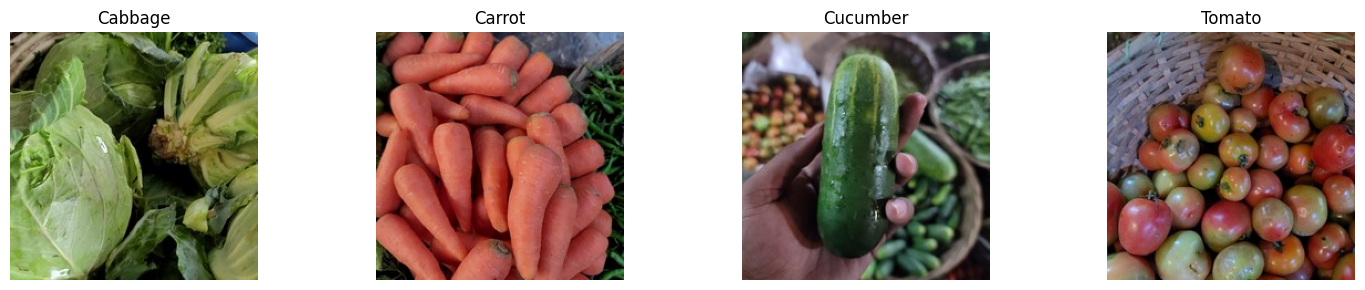

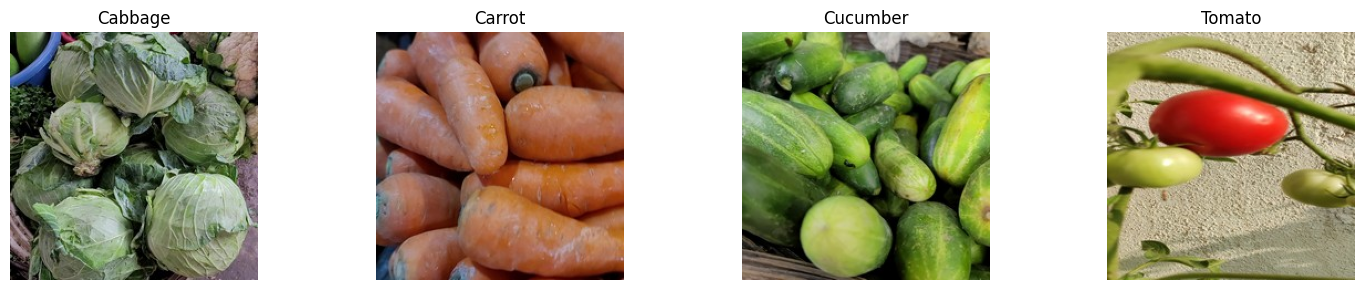

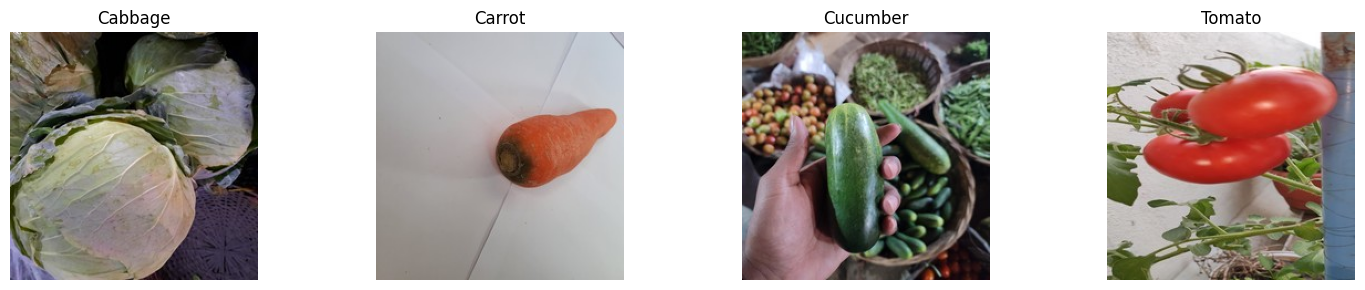

In [ ]:
visualize_imgs_from_dataset(image_datasets["train"], class_names, pts_per_class=3, color_scale=None)

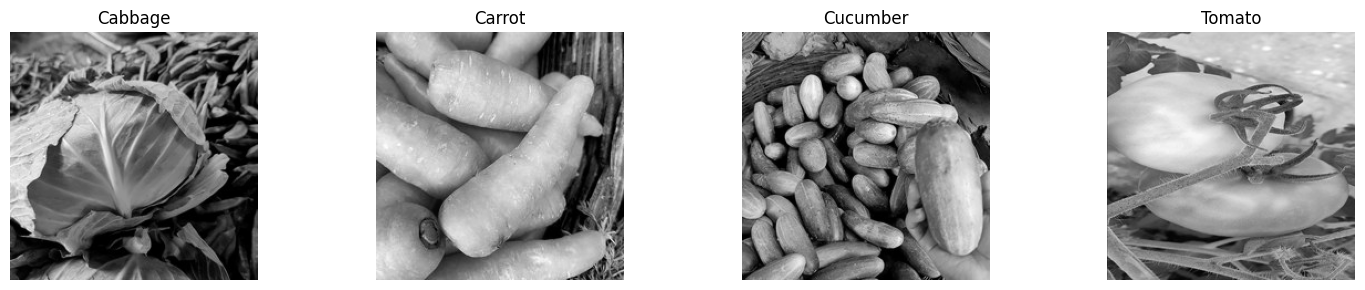

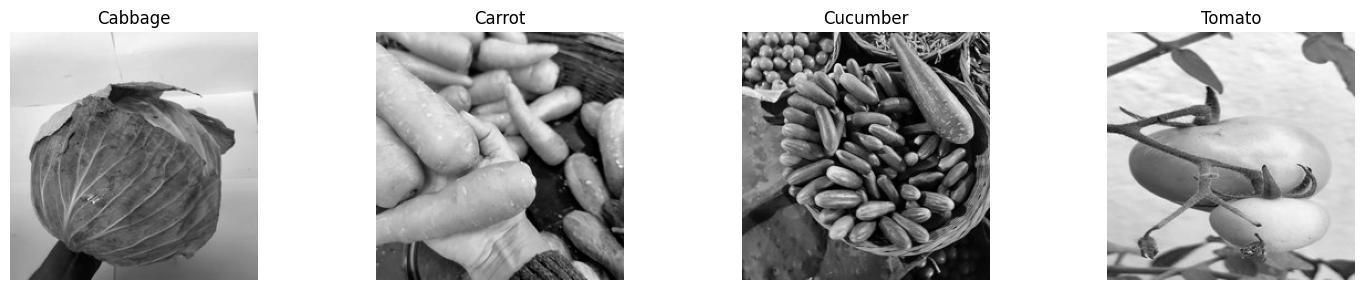

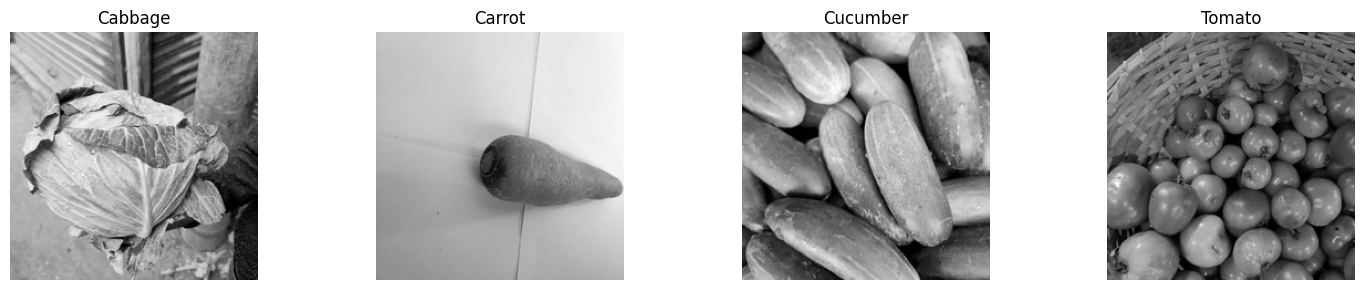

In [ ]:
visualize_imgs_from_dataset(image_datasets["train"], class_names, pts_per_class=3, color_scale='gray')

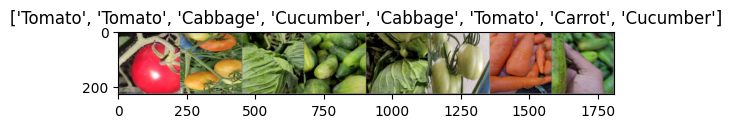

In [ ]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = inp * 0.5 + 0.5
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders["train"]))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[c] for c in classes])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def get_resnet18():
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))
    return model.to(device)
model = get_resnet18()
print(f"Using device: {device}")
print(model)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


Using device: cpu
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReL

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            epoch_precision = precision_score(all_labels, all_preds, average='weighted')
            epoch_recall = recall_score(all_labels, all_preds, average='weighted')

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} "
                  f"Precision: {epoch_precision:.4f} Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f}")

            # Log metrics to wandb
            wandb.log({
                f"{phase}_loss": epoch_loss,
                f"{phase}_accuracy": epoch_acc.item(),
                f"{phase}_precision": epoch_precision,
                f"{phase}_recall": epoch_recall,
                f"{phase}_f1": epoch_f1,
                "epoch": epoch + 1,
                **({ "learning_rate": scheduler.get_last_lr()[0] } if phase == 'train' else {})
            })

    return model


In [ ]:
def evaluate_model(model, dataloader, class_names, device):
    import wandb
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Log to WandB
    wandb.log({
        "eval_accuracy": acc,
        "eval_precision": precision,
        "eval_recall": recall,
        "eval_f1": f1,
        "eval_confusion_matrix": wandb.Image("confusion_matrix.png")
    })


In [ ]:

# Load models
resnet_model = get_resnet18()

# Define loss function
criterion = nn.CrossEntropyLoss()

# ResNet setup
optimizer_resnet = optim.SGD(resnet_model.parameters(), lr=0.001, momentum=0.9)
scheduler_resnet = optim.lr_scheduler.StepLR(optimizer_resnet, step_size=7, gamma=0.1)




In [ ]:
# Train model restnet
trained_resnet = train_model(resnet_model, dataloaders, criterion, optimizer_resnet, scheduler_resnet, num_epochs=10)

Epoch 1/10
Train Loss: 0.1627 Acc: 0.9471 Precision: 0.9472 Recall: 0.9471 F1: 0.9471
Validation Loss: 0.0027 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoch 2/10
Train Loss: 0.0911 Acc: 0.9736 Precision: 0.9736 Recall: 0.9736 F1: 0.9736
Validation Loss: 0.0019 Acc: 0.9988 Precision: 0.9988 Recall: 0.9988 F1: 0.9987
Epoch 3/10
Train Loss: 0.0444 Acc: 0.9863 Precision: 0.9863 Recall: 0.9863 F1: 0.9863
Validation Loss: 0.0003 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoch 4/10
Train Loss: 0.0475 Acc: 0.9855 Precision: 0.9855 Recall: 0.9855 F1: 0.9855
Validation Loss: 0.0003 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoch 5/10
Train Loss: 0.0390 Acc: 0.9855 Precision: 0.9855 Recall: 0.9855 F1: 0.9855
Validation Loss: 0.0004 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoch 6/10
Train Loss: 0.0274 Acc: 0.9923 Precision: 0.9923 Recall: 0.9923 F1: 0.9923
Validation Loss: 0.0010 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoc


Classification Report:

              precision    recall  f1-score   support

     Cabbage       0.00      0.00      0.00       200
      Carrot       0.11      0.06      0.08       200
    Cucumber       0.30      0.98      0.46       200
      Tomato       0.75      0.01      0.03       200

    accuracy                           0.27       800
   macro avg       0.29      0.26      0.14       800
weighted avg       0.29      0.27      0.14       800



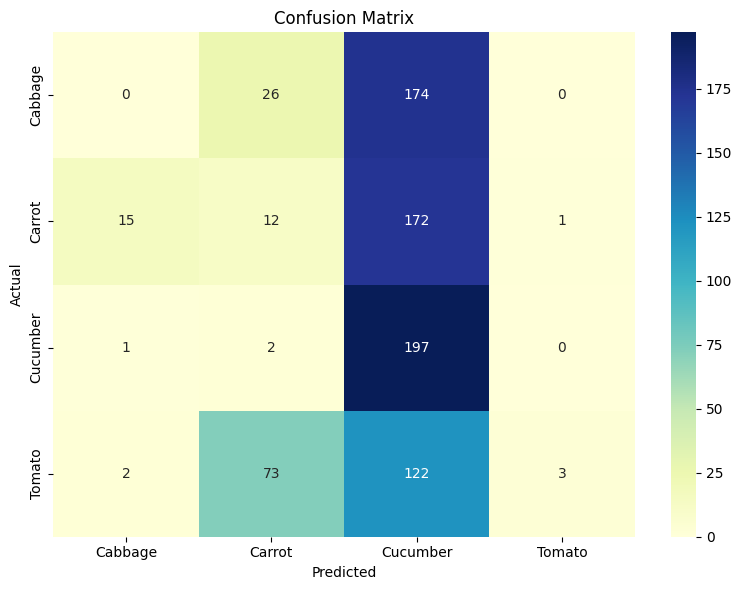

Accuracy: 0.2650
Precision: 0.2881
Recall: 0.2650
F1 Score: 0.1404


epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
eval_accuracy,▁
eval_f1,▁
eval_precision,▁
eval_recall,▁
learning_rate,██████▁▁▁▁
train_accuracy,▁▅▇▇▇█▇███
train_f1,▁▅▇▇▇█▇███
train_loss,█▅▂▂▂▁▂▁▁▁
train_precision,▁▅▇▇▇█▇███
train_recall,▁▅▇▇▇█▇███


In [ ]:
evaluate_model(model, dataloaders["test"], class_names, device)
wandb.finish()


In [ ]:
torch.save(model, "/content/drive/MyDrive/Vegetables_Classification_Project/Vegetable_Images/resnet18_model.pth")
